## Week 9
## Date : 4 Feb 2026

### Polynomial Linear Regression:

-Polynomial Regression is a form of linear regression where the relationship between the independent variable (x) and the dependent variable (y) is modelled as an nth degree polynomial.

-It is useful when the data exhibits a non-linear relationship allowing the model to fit a curve to the data.

Polynomial Regression हे regression algorithm आहे जे non-linear relationship handle करायला वापरतात.  
जेव्हा data straight line follow करत नाही तेव्हा polynomial regression वापरतात.

Polynomial Regression Formula (degree 2 example):

    Y = b0 + b1X + b2X1^2

- If degree increases:  
Curve becomes flexible  
Risk of overfitting increases

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [11]:
data = {
    "cgpa": [5, 6, 7, 8, 9],
    "package": [2, 3, 3.5, 5, 8]
}

df = pd.DataFrame(data)

X = df[["cgpa"]]
y = df["package"]
df.head()

,cgpa,package
0,5,2.0
1,6,3.0
2,7,3.5
3,8,5.0
4,9,8.0


In [4]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)


In [5]:
model = LinearRegression()
model.fit(X_poly, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


c:\Users\jadha\OneDrive\Desktop\gpp\Internship\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


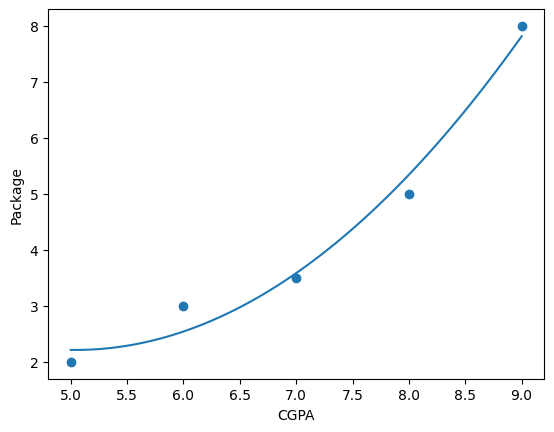

In [6]:
plt.scatter(X, y)

X_range = np.linspace(5, 9, 100).reshape(-1,1)
X_range_poly = poly.transform(X_range)

y_pred = model.predict(X_range_poly)

plt.plot(X_range, y_pred)
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.show()


#### Example 2

   Hours  Marks
0      1      5
1      2     15
2      3     30
3      4     50
4      5     80
5      6    120
6      7    170

Polynomial Features
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]
 [ 1.  7. 49.]]

Predicted Values
[  6.78571429  13.21428571  27.85714286  50.71428571  81.78571429
 121.07142857 168.57142857]


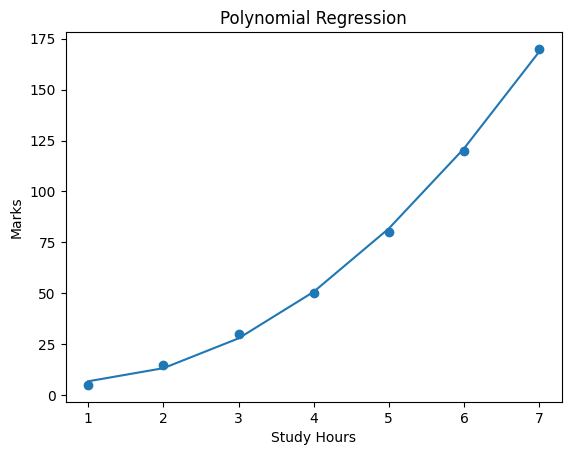

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# -----------------------------------
# Dataset
# -----------------------------------

data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7],
    'Marks': [5, 15, 30, 50, 80, 120, 170]
}

df = pd.DataFrame(data)

print(df)

# -----------------------------------
# Input and Output
# -----------------------------------

X = df[['Hours']]
y = df['Marks']

# -----------------------------------
# Polynomial Features
# -----------------------------------

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("\nPolynomial Features")
print(X_poly)

# -----------------------------------
# Model
# -----------------------------------

model = LinearRegression()

# Train
model.fit(X_poly, y)

# -----------------------------------
# Prediction
# -----------------------------------

y_pred = model.predict(X_poly)

print("\nPredicted Values")
print(y_pred)

# -----------------------------------
# Graph
# -----------------------------------

plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.title("Polynomial Regression")

plt.show()

| Hours | Marks |
| ----- | ----- |
| 1     | 5     |
| 2     | 15    |
| 3     | 30    |
| 4     | 50    |
| 5     | 80    |

इथे marks straight line मध्ये वाढत नाहीत.

ते curve pattern follow करतात.

### Overfitting and Underfitting

#### 1. Overfitting:

-ML model performs well on the training datta, but it does not generalize well called as overfitting

-Overfitting occurs when a model learns too much from training data, including noise and random fluctuations.

-It performs very well on training data but poorly on new (test) data.

- jar trainning data high and testing data low asel tar overfitting hoto


#### 2. Underfitting:

-ML model does not performs well on the training data and does not generaliza well called as underfitting.

-Underfitting occurs when a model is too simple to capture the underlying pattern of the data.

-The model cannot learn the relationship between input (X) and output (Y).

- jar training and testing donhi data low asatil tar underfitting hoto

#### difference between Underfitting and overfitting

| Feature           | Underfitting | Overfitting |
| ----------------- | ------------ | ----------- |
| Model             | Too Simple   | Too Complex |
| Training Accuracy | Low          | Very High   |
| Testing Accuracy  | Low          | Low         |
| Bias              | High         | Low         |
| Variance          | Low          | High        |


- Degree 1 → Straight line → Underfitting
- Degree 2 → Smooth curve → Good fit
- Degree 15 → Zig-zag curve → Overfitting

####  1️⃣ Underfitting (Polynomial Degree = 1)

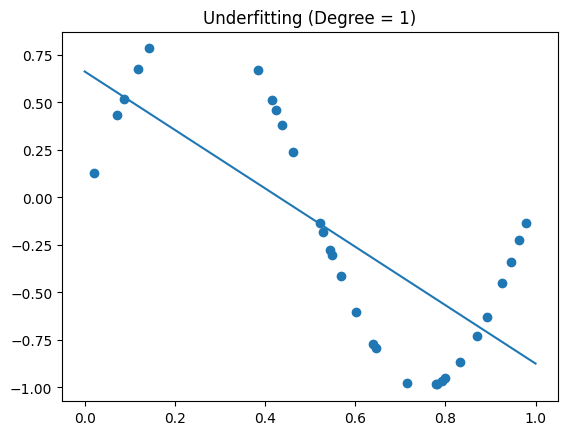

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Dataset
np.random.seed(0)
X = np.sort(np.random.rand(30, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel()

# Model (Degree 1)
model = make_pipeline(PolynomialFeatures(1), LinearRegression())
model.fit(X, y)

# Prediction
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot
plt.scatter(X, y)
plt.plot(X_test, y_pred)
plt.title("Underfitting (Degree = 1)")
plt.show()


#### 2️⃣ Good Fit (Polynomial Degree = 2)

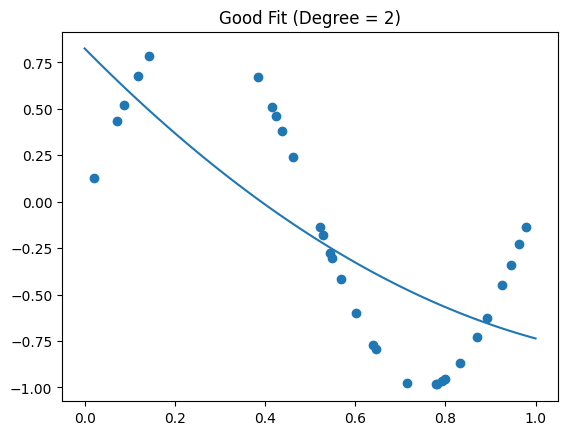

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Dataset
np.random.seed(0)
X = np.sort(np.random.rand(30, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel()

# Model (Degree 2)
model = make_pipeline(PolynomialFeatures(2), LinearRegression())
model.fit(X, y)

# Prediction
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot
plt.scatter(X, y)
plt.plot(X_test, y_pred)
plt.title("Good Fit (Degree = 2)")
plt.show()


#### 3️⃣ Overfitting (Polynomial Degree = 15)

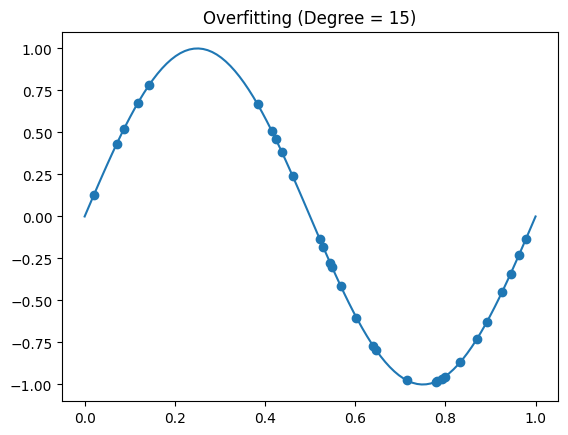

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Dataset
np.random.seed(0) # For reproducibility
X = np.sort(np.random.rand(30, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() 

# Model (Degree 15)
model = make_pipeline(PolynomialFeatures(15), LinearRegression())
model.fit(X, y)

# Prediction
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot
plt.scatter(X, y)
plt.plot(X_test, y_pred)
plt.title("Overfitting (Degree = 15)")
plt.show()


.